# Hyperspectral Object Tracking with SAM3

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cubert-hyperspectral/cuvis-ai/blob/main/notebooks/use_cases/object_tracking_passive.ipynb)

When visually similar people move through the same patch of ground, a conventional RGB tracker loses track: 
appearance cues — colour, texture, shape — are too similar to reliably distinguish identities.
A Cubert Ultris XMR records **61 spectral bands per pixel** (430–910 nm) at 15 Hz — far beyond
what the eye, or any RGB sensor, can resolve. Different fabrics, dyes, and coatings
scatter and absorb light differently across those extra bands, giving each outfit a
distinct *spectral fingerprint* even when the visible-light appearance is identical.

In this tutorial we build Cuvis.AI pipelines that use SAM3 (Meta's Segment Anything
Model 3) as a plugin node to perform concept segmentation and tracking. We feed SAM3
various source views by projecting the hyperspectral video cube into different
spectrums: we try RGB and CIR, plus a special view tuned for an invisible ink.

**Pipeline at a glance:**

```
CU3SDataNode ──► CIETristimulusRGBSelector ──► SAM3TextPropagation ──► TrackingOverlayNode ──► ToVideoNode
                                                ▲
                                          TextPrompt("person@0")
```

> **Prerequisites**
>
> 1. Install cuvis-ai — see the [Installation Guide](https://docs.cuvis.ai/latest/user-guide/installation/).
> 2. From the cuvis-ai env, launch the notebook with `uv run jupyter lab`.

In [ ]:
# Colab bootstrap — no-op when running locally
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q cuvis-ai "cuvis-ai-dataloader[cu3s,coco]"
    !which ffmpeg dot >/dev/null || echo "WARN: ffmpeg/dot missing on this runtime"

    import torch

    if not torch.cuda.is_available():
        print(
            "WARNING: No GPU detected. Switch via Runtime > Change runtime type > T4 GPU. "
            "CPU runs are slow (perfusion ~10x, SAM3 passive ~80x)."
        )

In [1]:
# ruff: noqa: E402
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import torch
from cuvis_ai_dataloader.data import Cu3sDataModule
from IPython.display import Image, Video, display
from loguru import logger

from cuvis_ai.node.anomaly_visualization import TrackingOverlayNode
from cuvis_ai.node.channel_selector import CIETristimulusRGBSelector, CIRSelector
from cuvis_ai.node.data import CU3SDataNode
from cuvis_ai.node.json_file import CocoTrackMaskWriter
from cuvis_ai.node.prompts import MaskPrompt, TextPrompt
from cuvis_ai.node.video import ToVideoNode, VideoFrameDataModule, VideoFrameNode
from cuvis_ai_core.data.public_datasets import PublicDatasets
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import Predictor
from cuvis_ai_core.utils.node_registry import NodeRegistry

In [2]:
device = torch.device("cpu")
# Pick the best available torch device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
logger.info(f"Using device {device}")

2026-04-30 10:48:47.082 | INFO     | __main__:<module>:7 - Using device cuda


## 1 · Fetch the dataset

The XMR Object Tracking dataset (~25 GB) lives on Hugging Face Hub. It contains
two recording sessions:

| Session | Folder | Scene |
|---------|--------|-------|
| **Passive** | `2026_04_15_16_28_10` | Three actors in identical outfits walk in single file, occluding one another. The target wears a garment that looks distinct in colour-infrared (CIR) even though it matches in the visible spectrum. |
| **Active** | `2026_04_20_16_28_54` | Midway through, the target is sprayed with "invisible" spectral ink visible only in specific NIR bands. See §13 for this mode. |

This tutorial uses the **passive session** for the main tracking pipeline.

In [3]:
dataset_dir = Path("/content/data") if IN_COLAB else Path("../../data")

_ = PublicDatasets.download_dataset(
    "demo_object_tracking",
    download_path=str(dataset_dir),
    force=False,
)

Dataset 'demo_object_tracking' already exists at ..\..\data\XMR_Demo_Object_Tracking
Use force=True to re-download.


## 2 · The visual ambiguity problem

Tracking a specific person in a crowd is hard when appearance cues
collapse. State-of-the-art video trackers such as SAM3 rely on colour,
texture, and shape to maintain identity across frames. Visual ambiguity
arises whenever those cues become non-discriminative in the RGB domain —
subjects in similar clothing, targets far from the camera, or partial
occlusions that expose only a sliver of the person. When
re-identification confidence drops, the tracker swaps IDs on the next
overlap.

**Why does hyperspectral video help?**

The visible spectrum covers roughly 380–740 nm. Standard RGB cameras
sample three broad bands in this range. The Cubert XMR samples **61
narrow bands from 430 to 910 nm**, extending well into the near-infrared.
In the NIR, many common fabric dyes, coatings, and chemical treatments
behave very differently from one another even when their visible-light
colour is indistinguishable. Two materials that match perfectly at 550 nm
may differ by 30 % or more in reflectance at 800 nm.

**CIE tristimulus** collapses the 61-band cube into three channels by
integrating against the CIE 1931 colour-matching functions ($\bar{x}$,
$\bar{y}$, $\bar{z}$) — the same response curves that define human
colour perception. The result is **true RGB**: what a conventional camera
would photograph if it were pointed at the same scene. This lets SAM3 run
in its native RGB mode without retraining or modification. Other
pipelines in this repository substitute a different selector — CIR or a
custom band combination — to feed the tracker a *false-RGB* view that
surfaces spectral features invisible in true colour.

The result: SAM3 receives a clean, calibrated RGB rendering of every
frame and can preserve target identity through visually ambiguous
conditions that cause an RGB-only tracker to swap.

**A note on tracking mode.** This pipeline uses `SAM3TextPropagation`
with the prompt `"person"` — a *class-level* tracker that segments all
people present. To lock onto one specific target instead, switch to
`SAM3MaskPropagation` and seed it with a single mask from one frame —
shown in §11 (RGB) and §12 (CIR).

## 3 · Tutorial configuration

Edit these variables to customise the run.

- **`PROCESSING_MODE`** — `"SpectralRadiance"` is correct for this dataset: no
  white reference was recorded, so reflectance calibration is not possible.
- **`TEXT_PROMPT`** — SAM3 text prompt injected at frame 0. `"person@0"` seeds a
  class-level tracker that finds all people. Append `@<frame>` to re-seed at a
  later frame, e.g. `"person@30"`.
- **`MASK_PROMPT_SPEC`** — seed for the §11–12 mask propagation, in the form
  `<object_id>:<detection_id>@<frame_id>`. `"1:3@20"` means *"track the third
  detection at frame 20 as object 1"*. The detections come from the COCO JSON
  written by §7.
- **`PREVIEW_FRAME_ID`** — frame index for the §6 sanity-check.
- **`FRAME_RATE`** — output video FPS (matches the sensor capture rate).

§7 caps the text-propagation run at 200 frames (hard-coded in that cell — SAM3
text propagation is the slowest step, so we keep it bounded). §10 (CIR), §11–12
(mask propagation) and §13 (active preview) all run on the full source video.

In [4]:
PROCESSING_MODE = "SpectralRadiance"
TEXT_PROMPT = "person@0"
MASK_PROMPT_SPEC = "1:3@20"  # assign tracker object_id=1 to detection_id=3 at source frame 20
PREVIEW_FRAME_ID = 50
FRAME_RATE = 15.0

output_dir = Path("./output/object_tracking")
output_dir.mkdir(parents=True, exist_ok=True)

# Outputs of the §5–7 text-propagation pipeline (consumed by §11–12):
output_video_path = output_dir / "tracking_overlay.mp4"  # SAM3 text-prop overlay video
rgb_video_path = output_dir / "rgb_video.mp4"  # clean CIE-tristimulus RGB video
output_json_path = output_dir / "tracking_results.json"  # COCO mask JSON used by MaskPrompt

# Outputs of §10 (CIR rendering) and §11–12 (mask propagation):
cir_video_path = output_dir / "cir_video.mp4"
mask_video_rgb_path = output_dir / "mask_propagation_rgb.mp4"
mask_video_cir_path = output_dir / "mask_propagation_cir.mp4"

passive_cu3s = (
    dataset_dir
    / "XMR_Demo_Object_Tracking"
    / "measurements"
    / "cu3s"
    / "2026_04_15_16_28_10"
    / "Auto_000.cu3s"
)

print(f"Passive CU3S:        {passive_cu3s}")
print(f"Text prompt:         {TEXT_PROMPT}")
print(f"Mask prompt spec:    {MASK_PROMPT_SPEC}")
print(f"Tracking overlay:    {output_video_path}")
print(f"Clean RGB video:     {rgb_video_path}")
print(f"Tracking JSON:       {output_json_path}")
print(f"CIR video:           {cir_video_path}")
print(f"Mask-prop RGB video: {mask_video_rgb_path}")
print(f"Mask-prop CIR video: {mask_video_cir_path}")

Passive CU3S:        ..\..\data\XMR_Demo_Object_Tracking\measurements\cu3s\2026_04_15_16_28_10\Auto_000.cu3s
Text prompt:         person@0
Mask prompt spec:    1:3@20
Tracking overlay:    output\object_tracking\tracking_overlay.mp4
Clean RGB video:     output\object_tracking\rgb_video.mp4
Tracking JSON:       output\object_tracking\tracking_results.json
CIR video:           output\object_tracking\cir_video.mp4
Mask-prop RGB video: output\object_tracking\mask_propagation_rgb.mp4
Mask-prop CIR video: output\object_tracking\mask_propagation_cir.mp4


## 4 · Load the SAM3 plugin

SAM3 is a plugin shipped separately from the Cuvis.AI core. `NodeRegistry` resolves
its package, downloads and caches the model weights on first use, and returns the
node class ready to instantiate like any built-in node.

The plugin manifest at `configs/plugins/sam3.yaml` lists the Git tag and the capability
class names for all SAM3 node variants
(`SAM3TextPropagation`, `SAM3MaskPropagation`, `SAM3BboxPropagation`, …).

In [5]:
PLUGINS_YAML = Path("../../configs/plugins/sam3.yaml")

registry = NodeRegistry()
registry.register_plugins(str(PLUGINS_YAML))
SAM3TextPropagation = registry.get("cuvis_ai_sam3.node.SAM3TextPropagation")

logger.success("SAM3TextPropagation loaded: {}", SAM3TextPropagation)

2026-04-30 10:48:47.100 | INFO     | cuvis_ai_core.utils.node_registry:_ensure_local_plugin:547 - Using local plugin 'sam3' at D:\code-repos\cuvis-ai-sam3\tracker-reset
2026-04-30 10:48:47.101 | DEBUG    | cuvis_ai_core.utils.git_and_os:_extract_deps_from_pyproject:265 - Extracted 25 dependencies from D:\code-repos\cuvis-ai-sam3\tracker-reset\pyproject.toml
2026-04-30 10:48:47.102 | INFO     | cuvis_ai_core.utils.git_and_os:_install_plugin_dependencies:246 - Installing 25 dependencies for plugin 'sam3'...
2026-04-30 10:48:47.102 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:273 - Dependencies to install: cuvis-ai-core>=0.3.4, cuvis-ai-schemas>=0.4.0, timm>=1.0.17, tqdm, ftfy==6.1.1, regex, iopath>=0.1.10, typing_extensions, huggingface_hub, einops, decord, triton-windows; platform_system == 'Windows', triton; platform_system != 'Windows', psutil, setuptools<81, opencv-python-headless>=4.13.0.92, click>=8.3.1, uvicorn>=0.41.0, pydantic>=2.12.5, pydantic-setti

## 5 · Build the tracking pipeline

Eight nodes, sixteen connections:

- `CU3SDataNode` unpacks each measurement into a `[B, H, W, C]` spectral cube,
  a 1-D wavelength vector, and a measurement index (`mesu_index`).
- `CIETristimulusRGBSelector` integrates the cube against CIE colour-matching
  functions to produce a normalised `[B, H, W, 3]` RGB frame.
- `TextPrompt` schedules text prompts at specific frame IDs; `"person@0"` emits
  `"person"` once at frame 0 to seed the tracker and nothing on subsequent frames.
- `SAM3TextPropagation` is stateful: it segments the prompt targets on the seeded
  frame and propagates the masks forward through the video stream.
- `TrackingOverlayNode` blends the predicted masks and object IDs onto the
  RGB frame as coloured outlines.
- `ToVideoNode` (overlay) encodes the annotated frames to `tracking_overlay.mp4`.
- `CocoTrackMaskWriter` records per-frame SAM3 detections to
  `tracking_results.json` so §11–12 can seed `MaskPrompt` from one of those
  detections.

In [6]:
pipeline = CuvisPipeline("HyperspectralTracking_SAM3_Text")

cu3s_data = CU3SDataNode(name="cu3s_data")
true_rgb = CIETristimulusRGBSelector(name="true_rgb")
text_prompt = TextPrompt(prompt_specs=[TEXT_PROMPT], name="text_prompt")
sam3_tracker = SAM3TextPropagation(
    checkpoint_path=None,
    compile_model=False,
    score_threshold_detection=0.5,
    new_det_thresh=0.7,
    det_nms_thresh=0.1,
    overlap_suppress_thresh=0.7,
    max_tracker_states=500,
    name="sam3_tracker",
)
overlay = TrackingOverlayNode(alpha=0.2, name="tracking_overlay")
to_video = ToVideoNode(
    output_video_path=str(output_video_path),
    frame_rate=FRAME_RATE,
    name="to_video",
)
tracking_json = CocoTrackMaskWriter(
    output_json_path=str(output_json_path),
    default_category_name="person",
    name="tracking_coco_json",
)

pipeline.connect(
    # Hyperspectral source → RGB
    (cu3s_data.outputs.cube, true_rgb.cube),
    (cu3s_data.outputs.wavelengths, true_rgb.wavelengths),
    # RGB + frame ID → SAM3 tracker
    (true_rgb.rgb_image, sam3_tracker.rgb_frame),
    (cu3s_data.outputs.mesu_index, sam3_tracker.inputs.frame_id),
    # Text prompt schedule → SAM3 tracker
    (cu3s_data.outputs.mesu_index, text_prompt.frame_id),
    (text_prompt.text_prompt, sam3_tracker.inputs.text_prompt),
    # SAM3 outputs + RGB → overlay
    (true_rgb.rgb_image, overlay.rgb_image),
    (cu3s_data.outputs.mesu_index, overlay.frame_id),
    (sam3_tracker.mask, overlay.mask),
    (sam3_tracker.object_ids, overlay.object_ids),
    # Overlay → tracking video
    (overlay.rgb_with_overlay, to_video.rgb_image),
    (cu3s_data.outputs.mesu_index, to_video.frame_id),
    # SAM3 outputs → COCO JSON (consumed by §11–12 MaskPrompt)
    (cu3s_data.outputs.mesu_index, tracking_json.frame_id),
    (sam3_tracker.mask, tracking_json.mask),
    (sam3_tracker.object_ids, tracking_json.object_ids),
    (sam3_tracker.detection_scores, tracking_json.detection_scores),
)

2026-04-30 10:48:48.845 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\object_tracking\HyperspectralTracking_SAM3_Text.png


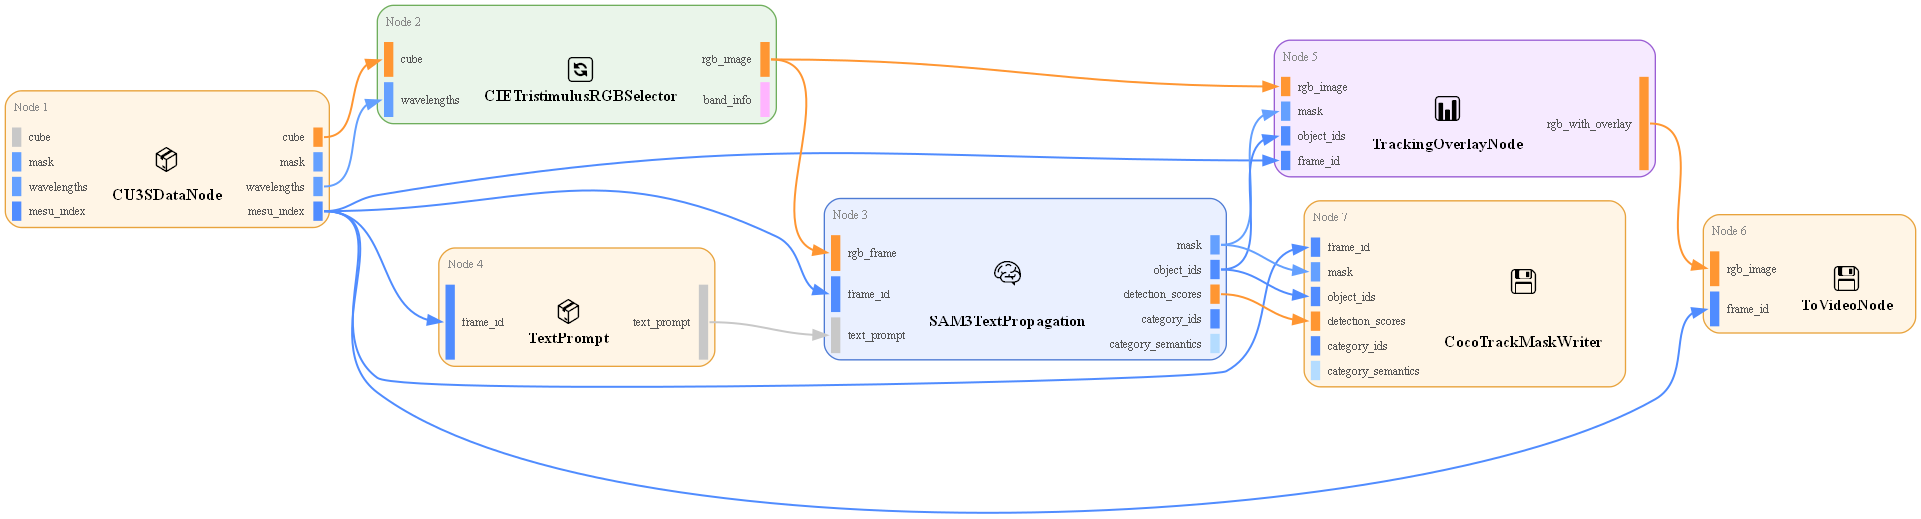

In [7]:
graph_png = pipeline.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{pipeline.name}.png"),
)
display(Image(str(graph_png)))

## 6 · Sanity-check: one RGB frame

Before committing to the full sweep, render a single frame end-to-end to verify
the RGB colours, orientation, and overall sanity — takes a few seconds.
`collect_outputs=True` captures intermediate tensors keyed by
`(node_name, port_name)` so we can pull and plot the RGB image inline.

*Note:* `ToVideoNode` writes a one-frame MP4 on this preview run; §7 overwrites
it on the full sweep.

Predict [HyperspectralTracking_SAM3_Text]:   0%|          | 0/1 [00:00<?, ?batch/s]

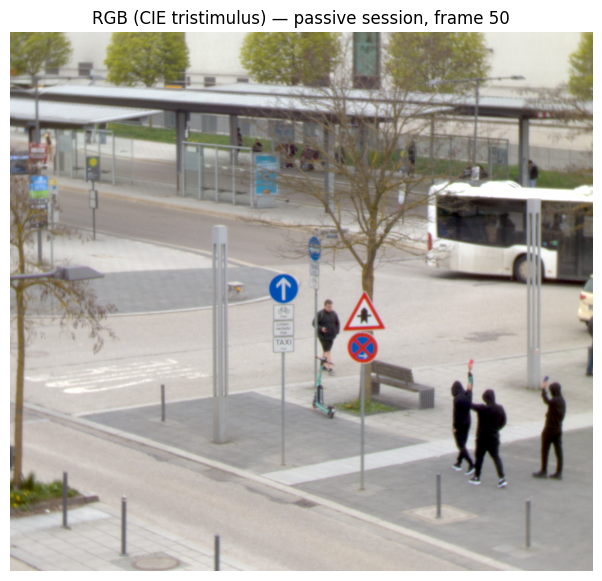

In [8]:
preview_datamodule = Cu3sDataModule(
    cu3s_file_path=str(passive_cu3s),
    processing_mode=PROCESSING_MODE,
    batch_size=1,
    measurement_indices=[PREVIEW_FRAME_ID],
)

pipeline.to(device)
preview_outputs = Predictor(pipeline=pipeline, datamodule=preview_datamodule).predict(
    collect_outputs=True
)

rgb_frame = preview_outputs[0][("true_rgb", "rgb_image")][0].cpu().numpy()

plt.figure(figsize=(9, 7))
plt.imshow(rgb_frame)
plt.title(f"RGB (CIE tristimulus) — passive session, frame {PREVIEW_FRAME_ID}")
plt.axis("off")
plt.show()

## 7 · Run the pipeline

`Predictor.predict` iterates batches from `Cu3sDataModule` and pushes each
through the connected pipeline. This run is capped at **200 frames** —
`max_batches=200` — because SAM3 text propagation is the slowest step and 200
frames (~13 s at 15 fps) is enough to show identity preservation through the
first occlusion. Drop the `max_batches` argument to process the full session.

SAM3 is stateful: the tracker seeds on the first frame where the text prompt
matches, then propagates forward. Re-instantiating the SAM3 node (or reconstructing
the pipeline) resets this state — useful if you want to run on a different clip.

In [9]:
datamodule = Cu3sDataModule(
    cu3s_file_path=str(passive_cu3s),
    processing_mode=PROCESSING_MODE,
    batch_size=1,
    measurement_indices=None,
)

pipeline.to(device)
predictor = Predictor(pipeline=pipeline, datamodule=datamodule)
predictor.predict(max_batches=90, collect_outputs=False)

for path in (output_video_path, output_json_path):
    if not path.exists():
        raise RuntimeError(f"Expected output was not created: {path}")

logger.success("Tracking overlay:    {}", output_video_path)
logger.success("Tracking COCO JSON:  {}", output_json_path)

Predict [HyperspectralTracking_SAM3_Text]:   0%|          | 0/90 [00:00<?, ?batch/s]

INFO 2026-04-30 10:49:00,313 46448 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
2026-04-30 10:49:03.203 | INFO     | cuvis_ai_sam3.node.sam3_streaming_propagation:_ensure_model:256 - SAM3 model loaded (image_size=1008, device=cuda:0, hotstart_delay=0)


propagate_in_video: 0it [00:00, ?it/s]

2026-04-30 10:51:03.206 | SUCCESS  | __main__:<module>:16 - Tracking overlay:    output\object_tracking\tracking_overlay.mp4
2026-04-30 10:51:03.207 | SUCCESS  | __main__:<module>:17 - Tracking COCO JSON:  output\object_tracking\tracking_results.json


## 8 · Watch the result

In [10]:
display(Video(str(output_video_path), embed=IN_COLAB, width=640))

### Free SAM3 GPU memory

SAM3 holds the loaded video model and per-stream tracker state on the GPU. Call `cleanup()` on the text-propagation tracker so the next pipeline starts with a clean slate — without this, repeated mask-propagation runs accumulate memory and slow down.

In [11]:
sam3_tracker.cleanup()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 9 · Render the full-length true-RGB video

§7 capped the SAM3 text-propagation run at 90 frames because text propagation is
the slowest step. The mask-propagation pipelines in §11 still need a *full-length*
true-RGB video to read frame-by-frame though, so we factor the CIE-tristimulus
rendering out of §5–7 and run it as its own pipeline here over every frame. The
shape is the same selector chain as §5, just without SAM3 in the middle:

```
CU3SDataNode ──► CIETristimulusRGBSelector ──► ToVideoNode
```


### 9.1 Build the true-RGB pipeline


2026-04-30 10:51:03.669 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\object_tracking\TrueRGB_Render.png


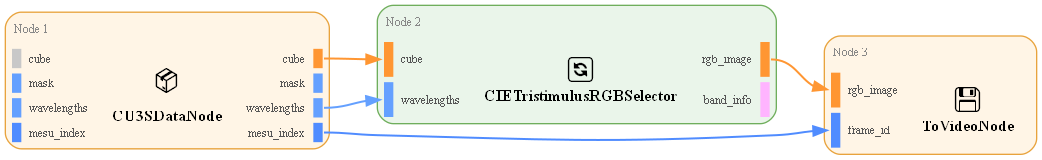

In [12]:
true_rgb_pipeline = CuvisPipeline("TrueRGB_Render")

true_rgb_cu3s_data = CU3SDataNode(name="cu3s_data")
true_rgb_selector = CIETristimulusRGBSelector(name="true_rgb")
true_rgb_to_video = ToVideoNode(
    output_video_path=str(rgb_video_path),
    frame_rate=FRAME_RATE,
    name="to_video",
)

true_rgb_pipeline.connect(
    (true_rgb_cu3s_data.outputs.cube, true_rgb_selector.cube),
    (true_rgb_cu3s_data.outputs.wavelengths, true_rgb_selector.wavelengths),
    (true_rgb_selector.rgb_image, true_rgb_to_video.rgb_image),
    (true_rgb_cu3s_data.outputs.mesu_index, true_rgb_to_video.frame_id),
)

true_rgb_graph_png = true_rgb_pipeline.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{true_rgb_pipeline.name}.png"),
)
display(Image(str(true_rgb_graph_png)))

### 9.2 Render the full true-RGB video

Run the pipeline over every frame in the passive session so the resulting
`rgb_video.mp4` is the full length of the source recording. §11 reads this file
frame-by-frame for mask propagation.


In [13]:
true_rgb_datamodule = Cu3sDataModule(
    cu3s_file_path=str(passive_cu3s),
    processing_mode=PROCESSING_MODE,
    batch_size=1,
    measurement_indices=None,
)

true_rgb_pipeline.to(device)
Predictor(pipeline=true_rgb_pipeline, datamodule=true_rgb_datamodule).predict(collect_outputs=False)

if not rgb_video_path.exists():
    raise RuntimeError(f"True-RGB video was not created: {rgb_video_path}")

logger.success("Clean RGB video: {}", rgb_video_path)

Predict [TrueRGB_Render]:   0%|          | 0/411 [00:00<?, ?batch/s]

2026-04-30 10:52:15.982 | SUCCESS  | __main__:<module>:14 - Clean RGB video: output\object_tracking\rgb_video.mp4


### 9.3 Watch the true-RGB video


In [14]:
display(Video(str(rgb_video_path), embed=IN_COLAB, width=640))

## 10 · CIR false-RGB rendering

CIR ("Color Infrared") is a false-RGB rendering of the hyperspectral cube where the
**near-infrared** band drives the red channel, **red** drives green, and **green** drives blue:

| Output channel | Source band  |
|----------------|--------------|
| R              | NIR ≈ 860 nm |
| G              | Red ≈ 670 nm |
| B              | Green ≈ 560 nm |

Vegetation reflects strongly in NIR and so glows bright red. More importantly for
this tutorial, garments that look identical in true RGB often differ markedly in NIR —
exactly the property that lets SAM3 mask propagation lock onto the right person in §12.

Like the passive section, we follow the *prepare data → build pipeline → run pipeline*
rhythm. The pipeline is `CU3SDataNode → CIRSelector → ToVideoNode`.

### 10.1 Build the CIR pipeline

```
CU3SDataNode ──► CIRSelector ──► ToVideoNode
```

2026-04-30 10:52:16.359 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\object_tracking\CIR_FalseRGB.png


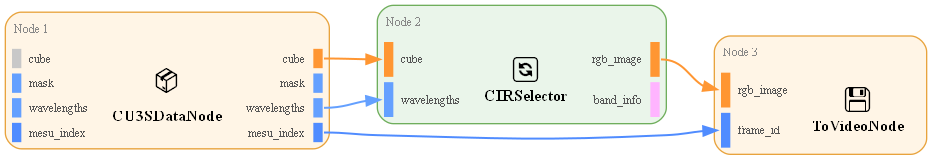

In [15]:
cir_pipeline = CuvisPipeline("CIR_FalseRGB")

cir_cu3s_data = CU3SDataNode(name="cu3s_data")
cir_selector = CIRSelector(nir_nm=860.0, red_nm=670.0, green_nm=560.0, name="cir_rgb")
cir_to_video = ToVideoNode(
    output_video_path=str(cir_video_path),
    frame_rate=FRAME_RATE,
    name="to_video",
)

cir_pipeline.connect(
    (cir_cu3s_data.outputs.cube, cir_selector.cube),
    (cir_cu3s_data.outputs.wavelengths, cir_selector.wavelengths),
    (cir_selector.rgb_image, cir_to_video.rgb_image),
    (cir_cu3s_data.outputs.mesu_index, cir_to_video.frame_id),
)

cir_graph_png = cir_pipeline.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{cir_pipeline.name}.png"),
)
display(Image(str(cir_graph_png)))

### 10.2 Preview a single frame

Render frame `PREVIEW_FRAME_ID` and place it next to the CIE-tristimulus rendering
from §6 — vegetation should glow red and any NIR-reflective fabric should pop out
relative to its true-RGB appearance.

Predict [CIR_FalseRGB]:   0%|          | 0/1 [00:00<?, ?batch/s]

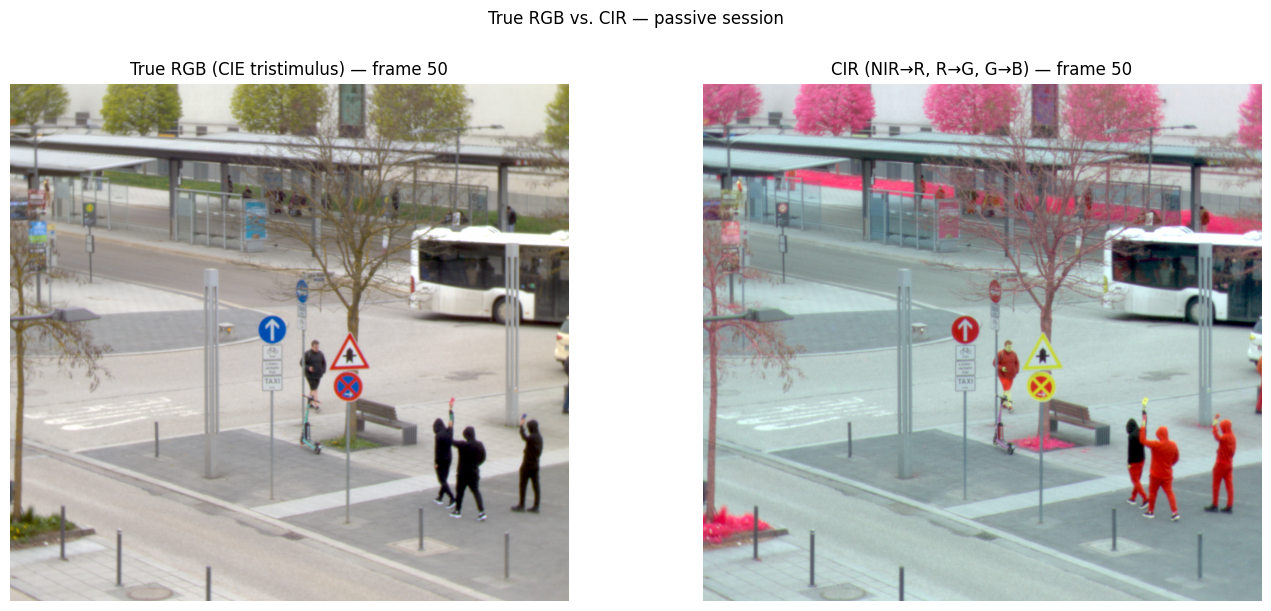

In [16]:
cir_preview_datamodule = Cu3sDataModule(
    cu3s_file_path=str(passive_cu3s),
    processing_mode=PROCESSING_MODE,
    batch_size=1,
    measurement_indices=[PREVIEW_FRAME_ID],
)

cir_pipeline.to(device)
cir_preview_outputs = Predictor(pipeline=cir_pipeline, datamodule=cir_preview_datamodule).predict(
    collect_outputs=True
)

cir_frame = cir_preview_outputs[0][("cir_rgb", "rgb_image")][0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(rgb_frame)
axes[0].set_title(f"True RGB (CIE tristimulus) — frame {PREVIEW_FRAME_ID}")
axes[0].axis("off")
axes[1].imshow(cir_frame)
axes[1].set_title(f"CIR (NIR→R, R→G, G→B) — frame {PREVIEW_FRAME_ID}")
axes[1].axis("off")
plt.suptitle("True RGB vs. CIR — passive session", y=1.01)
plt.tight_layout()
plt.show()

### 10.3 Render the full CIR video

Re-run the same pipeline over every frame to write `cir_video.mp4`. This file
becomes the input video for §12's mask-propagation pipeline.

In [17]:
cir_datamodule = Cu3sDataModule(
    cu3s_file_path=str(passive_cu3s),
    processing_mode=PROCESSING_MODE,
    batch_size=1,
    measurement_indices=None,
)

cir_pipeline.to(device)
Predictor(pipeline=cir_pipeline, datamodule=cir_datamodule).predict(collect_outputs=False)

if not cir_video_path.exists():
    raise RuntimeError(f"CIR video was not created: {cir_video_path}")

logger.success("CIR video: {}", cir_video_path)

Predict [CIR_FalseRGB]:   0%|          | 0/411 [00:00<?, ?batch/s]

2026-04-30 10:53:32.180 | SUCCESS  | __main__:<module>:14 - CIR video: output\object_tracking\cir_video.mp4


### 10.4 Watch the CIR video

In [18]:
display(Video(str(cir_video_path), embed=IN_COLAB, width=640))

## 11 · Mask propagation on the RGB video

`SAM3TextPropagation` (used in §5–8) tracks **everyone** the text prompt matches —
class-level tracking. To lock onto **one specific person** instead, we use
`SAM3MaskPropagation`: seed it with a single mask on a single frame, and it
propagates that mask through the rest of the video.

Two ingredients we already have from earlier sections:

- `rgb_video.mp4` — the clean CIE-tristimulus RGB rendering of every frame, written by §9.
- `tracking_results.json` — per-frame SAM3 detections in COCO format from §7. We pick one
  detection from this file as the seed mask, via `MASK_PROMPT_SPEC` (§3).

The pipeline reads frames from the MP4, so it bypasses the cu3s decode entirely. We
build the pipeline once here and reuse it on the CIR rendering in §12.

### 11.1 Prepare data

The pipeline used here:

```
VideoFrameNode ──► SAM3MaskPropagation ──► TrackingOverlayNode ──► ToVideoNode
                          ▲
                     MaskPrompt
                          ▲
                tracking_results.json
```

We could equally well decode the cu3s cube on the fly — the alternative pipeline:

```
CU3SDataNode ──► CIETristimulusRGBSelector ──► SAM3MaskPropagation ──► TrackingOverlayNode ──► ToVideoNode
                                                       ▲
                                                  MaskPrompt
```

Both forms produce the same overlay; the cu3s form re-renders the false-RGB on
every run, the video form reuses the cached MP4 we already wrote in §9. We use
the video form here.

In [19]:
for path in (rgb_video_path, output_json_path):
    if not path.exists():
        raise RuntimeError(
            f"Missing prerequisite: {path}. Run §5–7 (JSON) and §9 (RGB video) before this section."
        )

print(f"Source video:     {rgb_video_path}")
print(f"Detection JSON:   {output_json_path}")
print(f"Mask prompt spec: {MASK_PROMPT_SPEC}  (object_id : detection_id @ frame_id)")

Source video:     output\object_tracking\rgb_video.mp4
Detection JSON:   output\object_tracking\tracking_results.json
Mask prompt spec: 1:3@20  (object_id : detection_id @ frame_id)


### 11.2 Build the mask propagation pipeline

In [20]:
SAM3MaskPropagation = registry.get("cuvis_ai_sam3.node.SAM3MaskPropagation")

mask_pipeline_rgb = CuvisPipeline("MaskPropagation_RGB_Video")

video_frame_rgb = VideoFrameNode(name="video_frame")
mask_prompt_rgb = MaskPrompt(
    json_path=str(output_json_path),
    prompt_specs=[MASK_PROMPT_SPEC],
    name="mask_prompt",
)
sam3_mask_rgb = SAM3MaskPropagation(
    checkpoint_path=None,
    compile_model=False,
    score_threshold_detection=0.5,
    new_det_thresh=0.7,
    det_nms_thresh=0.1,
    overlap_suppress_thresh=0.7,
    max_tracker_states=5,
    name="sam3_mask",
)
overlay_rgb = TrackingOverlayNode(alpha=0.2, name="tracking_overlay")
to_video_rgb = ToVideoNode(
    output_video_path=str(mask_video_rgb_path),
    frame_rate=FRAME_RATE,
    name="to_video",
)

mask_pipeline_rgb.connect(
    # Video source → SAM3 tracker
    (video_frame_rgb.outputs.rgb_image, sam3_mask_rgb.rgb_frame),
    (video_frame_rgb.outputs.frame_id, sam3_mask_rgb.inputs.frame_id),
    # Mask prompt → SAM3 tracker
    (video_frame_rgb.outputs.frame_id, mask_prompt_rgb.frame_id),
    (mask_prompt_rgb.mask, sam3_mask_rgb.inputs.mask),
    # SAM3 outputs + RGB → overlay
    (video_frame_rgb.outputs.rgb_image, overlay_rgb.rgb_image),
    (video_frame_rgb.outputs.frame_id, overlay_rgb.frame_id),
    (sam3_mask_rgb.outputs.mask, overlay_rgb.mask),
    (sam3_mask_rgb.outputs.object_ids, overlay_rgb.object_ids),
    # Overlay → video
    (overlay_rgb.rgb_with_overlay, to_video_rgb.rgb_image),
    (video_frame_rgb.outputs.frame_id, to_video_rgb.frame_id),
)

2026-04-30 10:53:32.601 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\object_tracking\MaskPropagation_RGB_Video.png


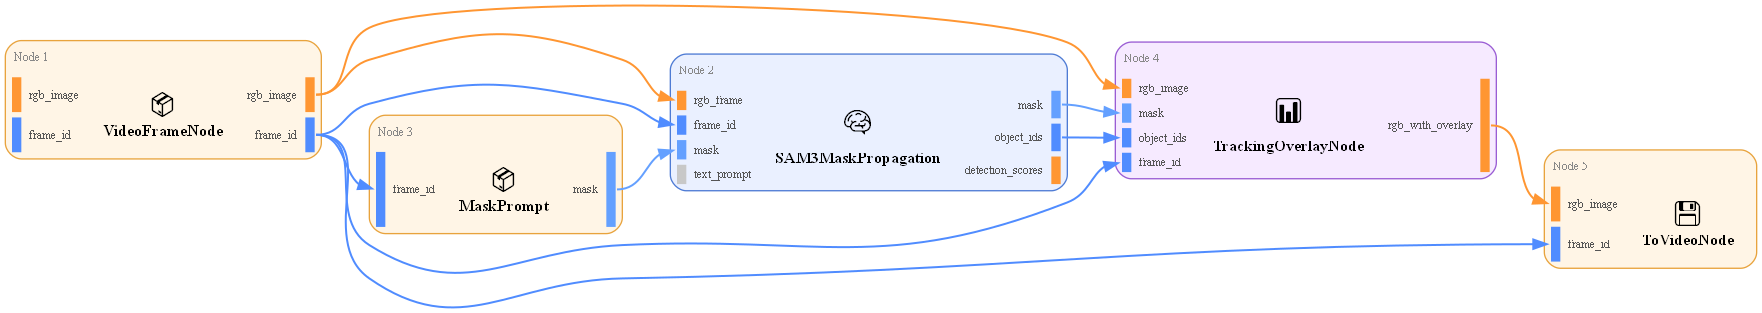

In [21]:
mask_graph_rgb_png = mask_pipeline_rgb.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{mask_pipeline_rgb.name}.png"),
)
display(Image(str(mask_graph_rgb_png)))

### 11.3 Run the mask propagation

In [22]:
mask_datamodule_rgb = VideoFrameDataModule(
    video_path=str(rgb_video_path),
    end_frame=-1,
    batch_size=1,
)

mask_pipeline_rgb.to(device)
Predictor(pipeline=mask_pipeline_rgb, datamodule=mask_datamodule_rgb).predict(collect_outputs=False)

if not mask_video_rgb_path.exists():
    raise RuntimeError(f"Mask-prop video was not created: {mask_video_rgb_path}")

logger.success("RGB mask-prop overlay: {}", mask_video_rgb_path)

Predict [MaskPropagation_RGB_Video]:   0%|          | 0/411 [00:00<?, ?batch/s]

INFO 2026-04-30 10:53:37,631 46448 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
2026-04-30 10:53:39.723 | INFO     | cuvis_ai_sam3.node.sam3_streaming_propagation:_ensure_model:256 - SAM3 model loaded (image_size=1008, device=cuda:0, hotstart_delay=0)


propagate_in_video: 0it [00:00, ?it/s]

2026-04-30 10:56:11.956 | SUCCESS  | __main__:<module>:13 - RGB mask-prop overlay: output\object_tracking\mask_propagation_rgb.mp4


### 11.4 Watch the mask-propagation overlay

In [23]:
display(Video(str(mask_video_rgb_path), embed=IN_COLAB, width=640))

## 12 · Mask propagation on the CIR video

We retarget the **same** `mask_pipeline_rgb` from §11 at the CIR rendering from §10
instead of building a second pipeline. The seed comes from the same
`tracking_results.json` and the same `MASK_PROMPT_SPEC` — frame indices in the
JSON are aligned to source measurements, so the same prompt picks the same person
in either rendering.

Why bother running mask propagation on CIR? When SAM3's appearance features
struggle on the true-RGB stream (visually similar clothing, low contrast), the
NIR-driven CIR rendering can give the tracker more spectral signal to lock onto.

### 12.1 Prepare data

In [24]:
for path in (cir_video_path, output_json_path):
    if not path.exists():
        raise RuntimeError(
            f"Missing prerequisite: {path}. Run §10 (CIR video) and §5–7 (JSON) first."
        )

print(f"Source video:     {cir_video_path}")
print(f"Detection JSON:   {output_json_path}")
print(f"Mask prompt spec: {MASK_PROMPT_SPEC}")

Source video:     output\object_tracking\cir_video.mp4
Detection JSON:   output\object_tracking\tracking_results.json
Mask prompt spec: 1:3@20


### 12.2 Run the mask propagation on CIR

In [25]:
# Reuse mask_pipeline_rgb on the CIR rendering. Predictor._reset_nodes() calls
# sam3_mask_rgb.reset() at the start of this predict() run, clearing the
# tracker's per-stream state while keeping the SAM3 model loaded on GPU.
# We just retarget the sink at the CIR output path — ToVideoNode.close() ran
# in §11's predict, so the next forward call will re-spawn ffmpeg lazily.
to_video_rgb.output_video_path = mask_video_cir_path

mask_datamodule_cir = VideoFrameDataModule(
    video_path=str(cir_video_path),
    end_frame=-1,
    batch_size=1,
)

mask_pipeline_rgb.to(device)
Predictor(pipeline=mask_pipeline_rgb, datamodule=mask_datamodule_cir).predict(collect_outputs=False)

if not mask_video_cir_path.exists():
    raise RuntimeError(f"Mask-prop video was not created: {mask_video_cir_path}")

logger.success("CIR mask-prop overlay: {}", mask_video_cir_path)

Predict [MaskPropagation_RGB_Video]:   0%|          | 0/411 [00:00<?, ?batch/s]

propagate_in_video: 0it [00:00, ?it/s]

2026-04-30 10:58:45.436 | SUCCESS  | __main__:<module>:20 - CIR mask-prop overlay: output\object_tracking\mask_propagation_cir.mp4


### 12.3 Watch the mask-propagation overlay

In [26]:
display(Video(str(mask_video_cir_path), embed=IN_COLAB, width=640))

### Free SAM3 GPU memory

The same `sam3_mask_rgb` tracker has now been used for both the §11 RGB and the
§12 CIR mask-propagation runs. SAM3 holds the loaded video model and per-stream
tracker state on the GPU — call `cleanup()` once here so the next pipeline starts
with a clean slate.

In [27]:
sam3_mask_rgb.cleanup()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 13 · Active tracking with invisible spectral ink

A second tracking mode lives in its own self-contained notebook: instead of relying on pre-existing spectral differences between garments, an actor sprays the target with NIR-fluorescent ink that is invisible to the eye and to any RGB camera, then a Spectral Angle Mapper (SPAM) deterministically locks onto that signature with no model and no training.

→ [`object_tracking_active.ipynb`](./object_tracking_active.ipynb)
